# Car Price Prediction with Machine Learning

## Aim
To analyze used car data and build a Machine Learning model for predicting car prices using Data Science techniques including:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Visualization
- Feature Engineering
- Machine Learning Model Building
- Model Evaluation
- Prediction System


## Dataset Information

Dataset Used:
Used Cars Price Prediction Dataset

Dataset Source:
https://www.kaggle.com/datasets/vijayaadithyanvg/car-price-predictionused-cars

This dataset contains information about used cars including:
- Brand
- Model
- Year
- Fuel Type
- Transmission
- Kilometers Driven
- Engine
- Mileage
- Price

The dataset is suitable for regression analysis and car price prediction.


## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [ ]:
# Install kagglehub
!pip install kagglehub -q

# Import libraries
import kagglehub
import os

# Download dataset directly from Kaggle
path = kagglehub.dataset_download(
    "vijayaadithyanvg/car-price-predictionused-cars"
)

print("Dataset downloaded to:", path)

# Show dataset files
print(os.listdir(path))

# Load dataset
car_df = pd.read_csv(os.path.join(path, "car data.csv"))

# Display dataset
car_df.head()

Using Colab cache for faster access to the 'car-price-predictionused-cars' dataset.
Dataset downloaded to: /kaggle/input/car-price-predictionused-cars
['car data.csv']


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Dataset Information

In [ ]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


### Observation
- Dataset contains categorical and numerical features.
- Suitable for Machine Learning regression tasks.

## Check Missing Values

In [ ]:
car_df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


## Check Duplicate Values

In [ ]:
car_df.duplicated().sum()

np.int64(2)

## Remove Duplicate Values

In [ ]:
car_df = car_df.drop_duplicates()

## Statistical Summary

In [ ]:
car_df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# Data Cleaning and Preprocessing

## Check Dataset Columns

In [ ]:
car_df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

## Encode Categorical Columns

In [ ]:
label_encoder = LabelEncoder()

categorical_columns = ['Fuel_Type', 'Selling_type', 'Transmission']

for col in categorical_columns:
    car_df[col] = label_encoder.fit_transform(car_df[col])

car_df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0


## Create Car Age Feature

In [ ]:
current_year = 2025

car_df['Car_Age'] = current_year - car_df['Year']

car_df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,2,0,1,0,11
1,sx4,2013,4.75,9.54,43000,1,0,1,0,12
2,ciaz,2017,7.25,9.85,6900,2,0,1,0,8
3,wagon r,2011,2.85,4.15,5200,2,0,1,0,14
4,swift,2014,4.60,6.87,42450,1,0,1,0,11


## Drop Unnecessary Columns

In [ ]:
car_df = car_df.drop(['Car_Name', 'Year'], axis=1)

car_df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,11
1,4.75,9.54,43000,1,0,1,0,12
2,7.25,9.85,6900,2,0,1,0,8
3,2.85,4.15,5200,2,0,1,0,14
4,4.60,6.87,42450,1,0,1,0,11


# Exploratory Data Analysis (EDA)

## Correlation Matrix

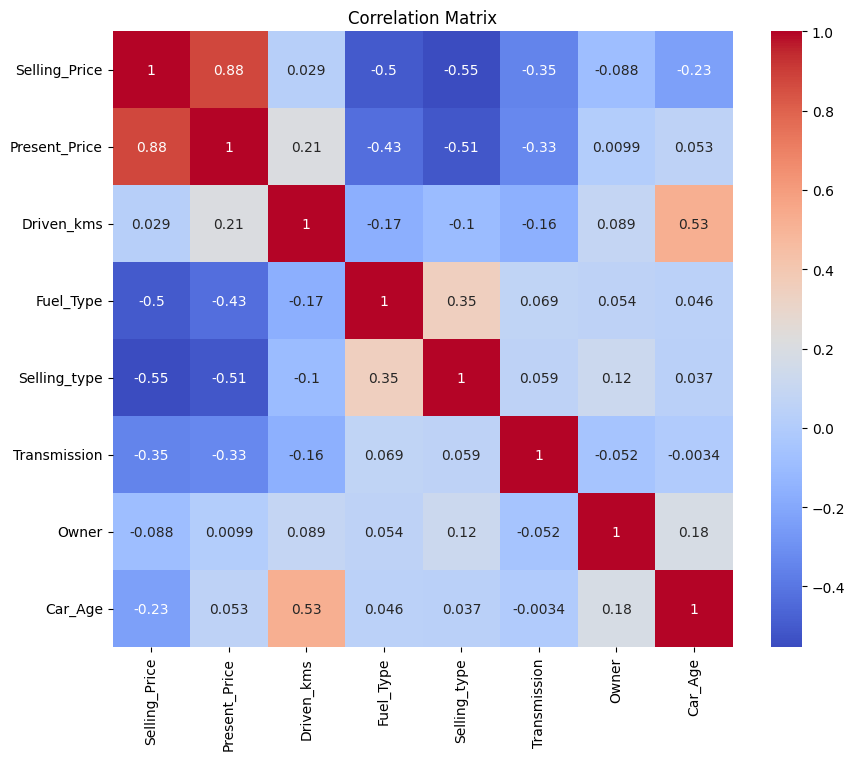

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(car_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

### Observation
- Present Price strongly affects Selling Price.
- Car Age negatively impacts Selling Price.

## Distribution of Selling Price

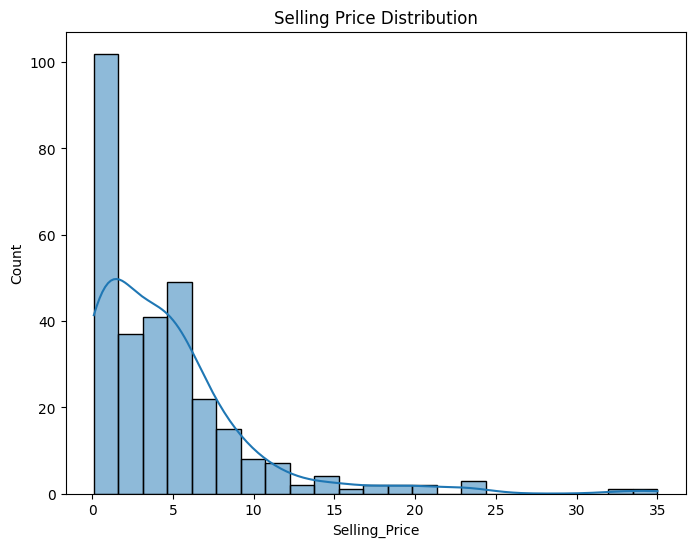

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(car_df['Selling_Price'], kde=True)

plt.title('Selling Price Distribution')
plt.show()

## Present Price vs Selling Price

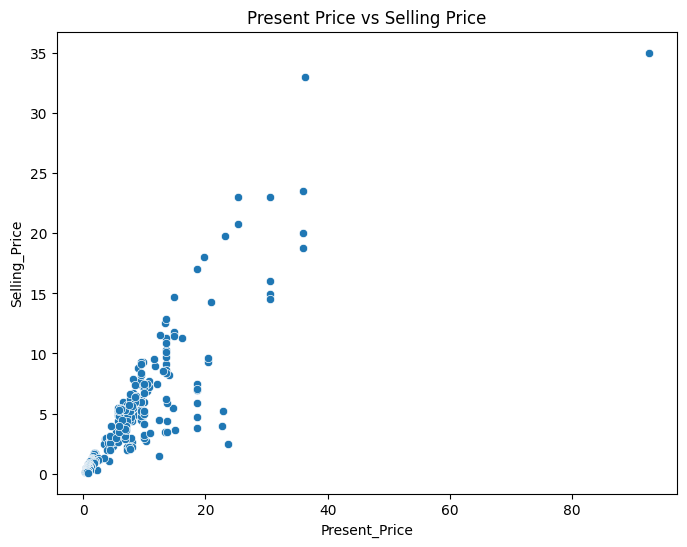

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Present_Price', y='Selling_Price', data=car_df)

plt.title('Present Price vs Selling Price')
plt.show()

## Car Age vs Selling Price

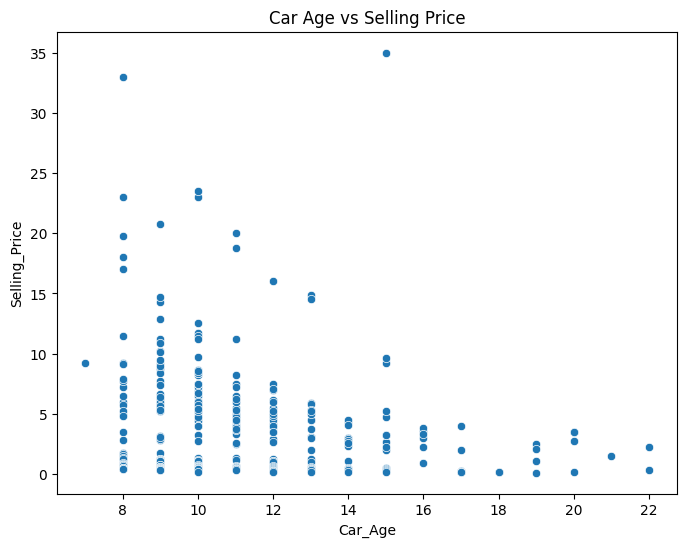

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Car_Age', y='Selling_Price', data=car_df)

plt.title('Car Age vs Selling Price')
plt.show()

## Fuel Type Count

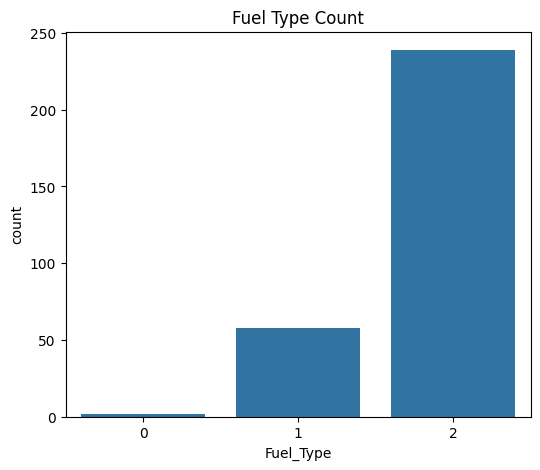

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='Fuel_Type', data=car_df)

plt.title('Fuel Type Count')
plt.show()

## Transmission Type Count

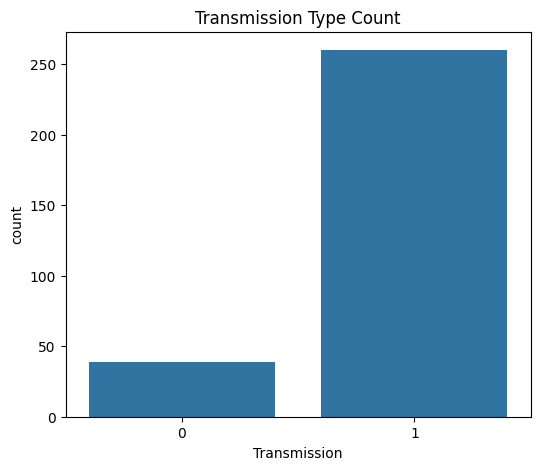

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='Transmission', data=car_df)

plt.title('Transmission Type Count')
plt.show()

# Business Insights

### Key Insights
- Cars with higher present price generally have higher selling price.
- Older cars have lower resale value.
- Fuel type and transmission influence car prices.
- Automatic transmission cars generally maintain higher value.
- Car age is an important factor for prediction.


# Machine Learning - Car Price Prediction

## Prepare Features and Target

In [ ]:
X = car_df.drop('Selling_Price', axis=1)
y = car_df['Selling_Price']

## Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Random Forest Regressor Model

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Predict Test Data

In [ ]:
y_pred = model.predict(X_test)

## Compare Actual and Predicted Values

In [ ]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head()

,Actual Price,Predicted Price
283,8.99,9.4393
267,8.35,8.2770
166,0.45,0.4401
9,7.45,6.8680
78,5.25,16.5640


## Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)

Mean Absolute Error: 1.412970000000001
Mean Squared Error: 11.15111805666667
Root Mean Squared Error: 3.3393289829944384
R2 Score: 0.5673377331701552


### Observation
- Lower error values indicate better prediction performance.
- High R2 score indicates strong model accuracy.

## Actual vs Predicted Price Graph

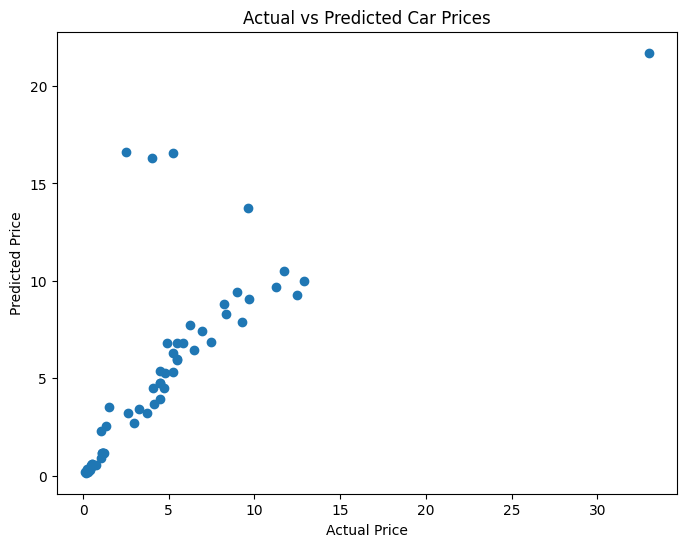

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

## Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
0,Present_Price,0.909067
6,Car_Age,0.068192
1,Driven_kms,0.014157
4,Transmission,0.004800
3,Selling_type,0.002028
2,Fuel_Type,0.001747
5,Owner,0.000009


## Predict New Car Price

In [ ]:
sample_data = pd.DataFrame({
    'Present_Price': [5.59],
    'Driven_kms': [27000],
    'Fuel_Type': [1],
    'Selling_type': [0],
    'Transmission': [1],
    'Owner': [0],
    'Car_Age': [7]
})

predicted_price = model.predict(sample_data)

print('Predicted Car Price:', predicted_price[0])

Predicted Car Price: 4.0005000000000015


# End-to-End Data Science Workflow

## Workflow Followed
1. Data Collection
2. Data Cleaning
3. Data Preprocessing
4. Exploratory Data Analysis
5. Feature Engineering
6. Machine Learning Model Building
7. Model Evaluation
8. Prediction System

This project follows a complete End-to-End Data Science workflow as required in industry-level projects.


# Conclusion
- Used car data was analyzed successfully.
- EDA and visualization techniques were applied.
- Important business insights were identified.
- Random Forest model successfully predicted car prices.
- Present Price and Car Age were highly important features.
